In [11]:
import numpy as np
import os,glob
from pathlib import Path
from helper import deltaR, electron_reco

from computeEfficiencies import getSR,preSelection,getObjects,passTrigger
DelphesLLP_path = Path(os.path.abspath("./DelphesLLP"))
os.environ['ROOT_INCLUDE_PATH'] = os.path.join(DelphesLLP_path,"external")

import ROOT
ROOT.gSystem.Load(os.path.join(DelphesLLP_path,"libDelphes.so"))
ROOT.gInterpreter.Declare('#include "classes/SortableObject.h"')
ROOT.gInterpreter.Declare('#include "classes/DelphesClasses.h"')
ROOT.gInterpreter.Declare('#include "external/ExRootAnalysis/ExRootTreeReader.h"')
from ROOT import TFile
# Cosmetics:
import matplotlib.pyplot as plt

import seaborn as sns
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica"]})
sns.set_style('ticks',{'font.family':'Times New Roman', 'font.serif':'Times New Roman'})
sns.set_context('paper', font_scale=1.8)
cm = plt.colormaps['RdYlBu']
cm_rev = plt.colormaps['RdYlBu_r']

In [12]:
# inputFile = './pp2selsel/Events/run_09/selectron_400GeV_1.000ns_delphes_events.root'
# inputFile = './pp2selsel_scan/Events/run_06/selectron_100GeV_0.100ns_delphes_events.root'
mass = 100.0
tau0 = 1.0
inputFile = list(glob.glob(f'./pp2selsel_scan/Events/run_*/selectron_{int(mass)}GeV_{tau0:.3f}ns_delphes_events.root'))[0]


f = TFile(inputFile,'read')
DelphesTree = f.Get('Delphes')
nevts = DelphesTree.GetEntries()

totalweight = 0
ct=0

d0A = []
d0B = []
pTA = []
pTB = []
effA = []
effB = []
effA_smooth = []
effB_smooth = []
for entry in range(nevts):
    DelphesTree.GetEntry(entry)
    ct+=1

    weight = float(DelphesTree.Weight.At(0).Weight)    
    totalweight += weight
    _,muons,electrons = getObjects(DelphesTree)
    leptons_preSel = preSelection(muons,electrons)
    if not leptons_preSel:
        continue
    if any(lep.PT < 65. for lep in leptons_preSel):
        continue
    if any(abs(lep.D0) < 3. for lep in leptons_preSel):
        continue
    # if any(abs(lep.D0) > 300. for lep in leptons_preSel):
        # continue
    if len(leptons_preSel) < 2:
        continue
    if any(abs(lep.PID) != 11 for lep in leptons_preSel):
        continue
    if deltaR(leptons_preSel[0], leptons_preSel[1]) < 0.2:
            continue
    if not passTrigger(leptons_preSel):
        continue

    eff_reco_A = electron_reco.efficiency(method='binned',Lepton_p_textT_GeV=leptons_preSel[0].PT, 
                                    Lepton_d_0_mm=abs(leptons_preSel[0].D0))
    eff_reco_B = electron_reco.efficiency(method='binned',Lepton_p_textT_GeV=leptons_preSel[1].PT, 
                                    Lepton_d_0_mm=abs(leptons_preSel[1].D0))
    
    eff_reco_A_smooth = electron_reco.efficiency(method='smooth',Lepton_p_textT_GeV=leptons_preSel[0].PT, 
                                    Lepton_d_0_mm=abs(leptons_preSel[0].D0))
    eff_reco_B_smooth = electron_reco.efficiency(method='smooth',Lepton_p_textT_GeV=leptons_preSel[1].PT, 
                                    Lepton_d_0_mm=abs(leptons_preSel[1].D0))
    
    # if eff_reco_A == 0. or eff_reco_B == 0.:
    #     print(f"eff A = {eff_reco_A}, eff B = {eff_reco_B}")
    #     print(f"pT A = {leptons_preSel[0].PT}, d0 A = {leptons_preSel[0].D0}")
    #     print(f"pT B = {leptons_preSel[1].PT}, d0 B = {leptons_preSel[1].D0}")
    #     break
    d0A.append(abs(leptons_preSel[0].D0))
    d0B.append(abs(leptons_preSel[1].D0))
    pTA.append(leptons_preSel[0].PT)
    pTB.append(leptons_preSel[1].PT)
    effA.append(eff_reco_A)
    effB.append(eff_reco_B)
    effA_smooth.append(eff_reco_A_smooth)
    effB_smooth.append(eff_reco_B_smooth)

In [13]:
# Efficiency edges from ATLAS
edges = np.array([[65.,300.],[135.,300.],[205.,300.],[205.,250.],[275.,250.],[345.,250.],[345.,200.],[415.,200.],[415.,150.],[485.,150.],[555.,150.],[555.,100.],[770.,100.]])

In [14]:
nA_fail = 0
nB_fail = 0
for pA,dA in zip(pTA,d0A):
    i = np.searchsorted(edges[:,0], pA)
    if i == len(edges):
        d0max = 0.0
    else:
        d0max = edges[:,1][i]
    if dA > d0max:
        nA_fail += 1
print(f"Fractions of failed entries for leading lepton: {float(nA_fail)/len(pTA):.2f} ({nA_fail} out of {len(pTA)})")

for pB,dB in zip(pTB,d0B):
    i = np.searchsorted(edges[:,0], pB)
    if i == len(edges):
        d0max = 0.0
    else:
        d0max = edges[:,1][i]
    if dB > d0max:
        nB_fail += 1
print(f"Fractions of failed entries for subleading lepton: {float(nB_fail)/len(pTB):.2f} ({nB_fail} out of {len(pTB)})")


Fractions of failed entries for leading lepton: 0.13 (511 out of 3988)
Fractions of failed entries for subleading lepton: 0.15 (615 out of 3988)


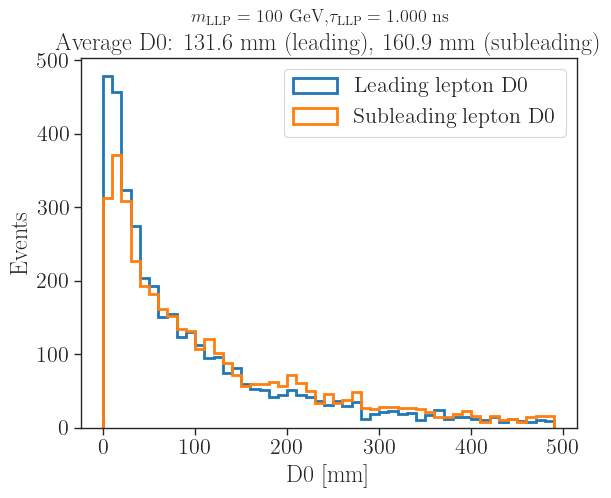

In [15]:
plt.hist(d0A,bins=np.arange(0,500,10).tolist(),histtype='step',label='Leading lepton D0',linewidth=2)
plt.hist(d0B,bins=np.arange(0,500,10).tolist(),histtype='step',label='Subleading lepton D0',linewidth=2)
plt.xlabel('D0 [mm]')
plt.ylabel('Events')
plt.title(f'Average D0: {np.mean(d0A):.1f} mm (leading), {np.mean(d0B):.1f} mm (subleading)')
plt.suptitle(r'$m_{\rm LLP} =$' + f' {mass:.0f} GeV,' + r'$\tau_{\rm LLP} =$' +  f' {tau0:.3f} ns', fontsize=13)
plt.legend()
plt.show()

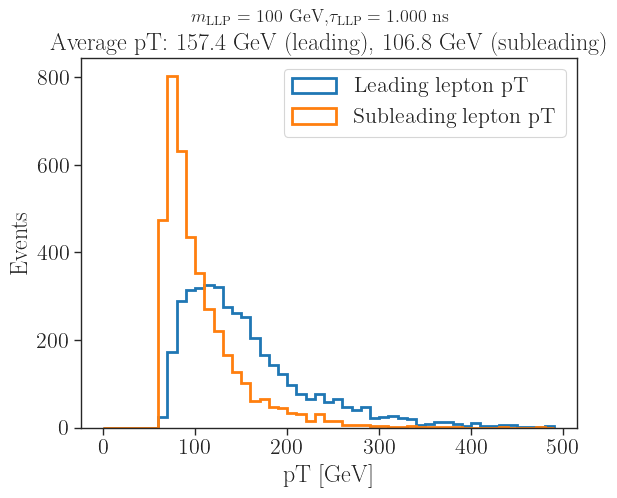

In [16]:
plt.hist(pTA,bins=np.arange(0,500,10).tolist(),histtype='step',label='Leading lepton pT',linewidth=2)
plt.hist(pTB,bins=np.arange(0,500,10).tolist(),histtype='step',label='Subleading lepton pT',linewidth=2)
plt.xlabel('pT [GeV]')
plt.ylabel('Events')
plt.title(f'Average pT: {np.mean(pTA):.1f} GeV (leading), {np.mean(pTB):.1f} GeV (subleading)')
plt.suptitle(r'$m_{\rm LLP} =$' + f' {mass:.0f} GeV,' + r'$\tau_{\rm LLP} =$' +  f' {tau0:.3f} ns', fontsize=13)
plt.legend()
plt.show()

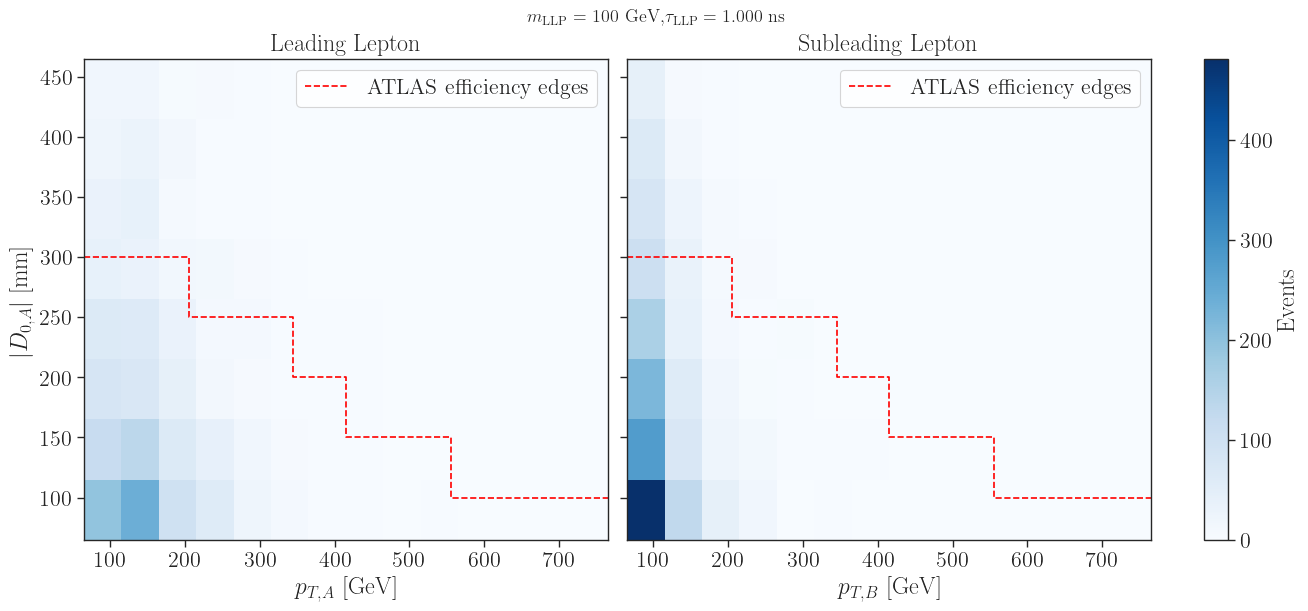

In [17]:
xbins = np.arange(65.0, 800., 50.)
ybins = np.arange(65.0, 500, 50.)

fig, axes = plt.subplots(1, 2, figsize=(13, 6), sharey=True, constrained_layout=True)

hist_a = axes[0].hist2d(pTA, d0A, bins=[xbins, ybins], cmap='Blues')
axes[0].set_xlabel(r'$p_{T,A}$ [GeV]')
axes[0].set_ylabel(r'$|D_{0,A}|$ [mm]')
axes[0].set_title('Leading Lepton')


hist_b = axes[1].hist2d(pTB, d0B, bins=[xbins, ybins], cmap='Blues')
axes[1].set_xlabel(r'$p_{T,B}$ [GeV]')
axes[1].set_title('Subleading Lepton')

axes[0].plot(edges[:,0], edges[:,1], color='red', linestyle='--', label='ATLAS efficiency edges')
axes[0].vlines(x=65.,ymin=3.,ymax=300.,color='red', linestyle='--')
axes[0].legend()
axes[1].plot(edges[:,0], edges[:,1], color='red', linestyle='--', label='ATLAS efficiency edges')
axes[1].vlines(x=65.,ymin=3.,ymax=300.,color='red', linestyle='--')
axes[1].legend()

vmax = max(hist_a[0].max(), hist_b[0].max())
hist_a[3].set_clim(0, vmax)
hist_b[3].set_clim(0, vmax)
fig.colorbar(hist_a[3], ax=axes, label='Events')
plt.suptitle(r'$m_{\rm LLP} =$' + f' {mass:.0f} GeV,' + r'$\tau_{\rm LLP} =$' +  f' {tau0:.3f} ns', fontsize=13)
plt.show()


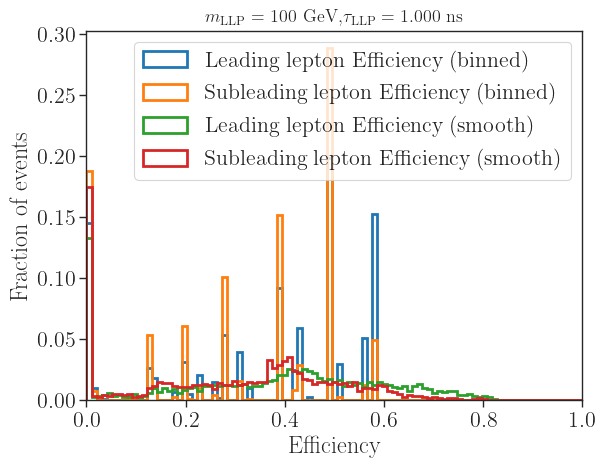

In [18]:
plt.hist(effA,bins=np.linspace(0,1,100).tolist(),histtype='step',label='Leading lepton Efficiency (binned)',linewidth=2,weights=np.ones_like(effA)/len(effA))
plt.hist(effB,bins=np.linspace(0,1,100).tolist(),histtype='step',label='Subleading lepton Efficiency (binned)',linewidth=2,weights=np.ones_like(effB)/len(effB))
plt.hist(effA_smooth,bins=np.linspace(0,1,100).tolist(),histtype='step',label='Leading lepton Efficiency (smooth)',linewidth=2,weights=np.ones_like(effA)/len(effA))
plt.hist(effB_smooth,bins=np.linspace(0,1,100).tolist(),histtype='step',label='Subleading lepton Efficiency (smooth)',linewidth=2,weights=np.ones_like(effB)/len(effB))
plt.xlabel('Efficiency')
plt.ylabel('Fraction of events')
plt.xlim(0.,1.0)
plt.legend()
plt.title(r'$m_{\rm LLP} =$' + f' {mass:.0f} GeV,' + r'$\tau_{\rm LLP} =$' +  f' {tau0:.3f} ns', fontsize=13)
plt.show()

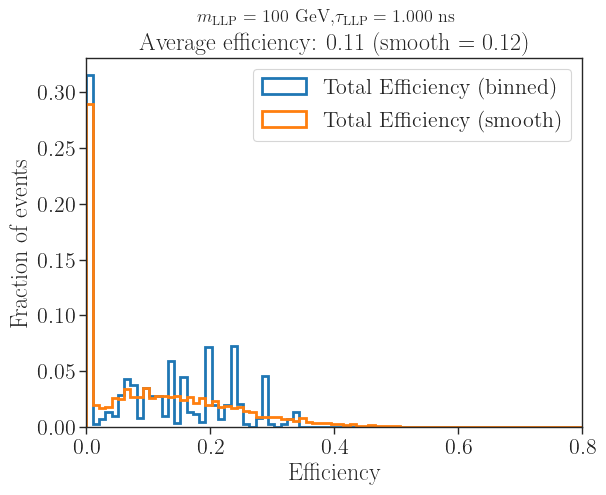

In [19]:
effTot = [eA*eB for eA,eB in zip(effA,effB)]
effTot_smooth = [eA*eB for eA,eB in zip(effA_smooth,effB_smooth)]
plt.hist(effTot,bins=np.linspace(0,1,100).tolist(),histtype='step',label='Total Efficiency (binned)',linewidth=2,weights=np.ones_like(effA)/len(effA))
plt.hist(effTot_smooth,bins=np.linspace(0,1,100).tolist(),histtype='step',label='Total Efficiency (smooth)',linewidth=2,weights=np.ones_like(effA)/len(effA))
plt.xlabel('Efficiency')
plt.ylabel('Fraction of events')
plt.xlim(0.,0.8)
plt.legend()
plt.title(f'Average efficiency: {np.mean(effTot):.2f} (smooth = {np.mean(effTot_smooth):.2f})')
plt.suptitle(r'$m_{\rm LLP} =$' + f' {mass:.0f} GeV,' + r'$\tau_{\rm LLP} =$' +  f' {tau0:.3f} ns', fontsize=13)
plt.show()